In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('ggplot')

In [79]:
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline, make_pipeline
from scipy.stats import skew
from sklearn.decomposition import PCA, KernelPCA
from xgboost import XGBRegressor

In [47]:
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.linear_model import ElasticNet, SGDRegressor, BayesianRidge
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor

In [48]:
pd.set_option('display.max_columns',500)
pd.set_option('display.max_rows',1000)

In [49]:
train=pd.read_csv('./X_train.csv')
test=pd.read_csv('./X_test.csv')
price_res=pd.read_csv('./y_train.csv')
train = pd.merge(train, price_res, on="Id") 

# data preprocessing

In [83]:
train .columns
for col in train.columns:
    print(col,train[col].dtype)

Id int64
鄉鎮市區 object
交易標的 object
路名 object
土地移轉總面積平方公尺 float64
都市土地使用分區 object
土地數 float64
建物數 float64
車位數 float64
移轉層次 int64
移轉層次項目 object
總樓層數 float64
建物型態 object
主要用途 object
主要建材 object
建築完成年月 object
建物移轉總面積平方公尺 float64
建物現況格局-房 int64
建物現況格局-廳 int64
建物現況格局-衛 int64
建物現況格局-隔間 object
有無管理組織 object
交易年 int64
交易日 int64
交易月 int64
地鐵站 float64
超商 float64
公園 float64
托兒所 float64
國小 float64
國中 float64
高中職 float64
大學 float64
金融機構 float64
醫院 float64
大賣場 float64
超市 float64
百貨公司 float64
警察局 float64
消防局 float64
縱坐標 float64
橫坐標 float64
單價元平方公尺 float64


In [117]:
full = train

### deal with years

In [118]:
# Convert '建築完成年月' to datetime format
full['建築完成年月'] = pd.to_datetime(full['建築完成年月'])

# Get the current date
today = datetime.today()

df = pd.DataFrame()


df['date_str'] = full['交易年'].astype(str) + '-' + full['交易月'].astype(str).str.zfill(2) + '-' + full['交易日'].astype(str).str.zfill(2)
df['交易日期'] = pd.to_datetime(df['date_str'])
#ˋ計算交易時屋齡
full['建築年紀']=df['交易日期'].dt.year- full['建築完成年月'].dt.year


print(full['建築年紀'])
#
full['交易距今時間'] = ((today.year - df['交易日期'].dt.year) * 12) + (today.month - df['交易日期'].dt.month)

print(full['交易距今時間'])


0        0
1       24
2       11
3       10
4       48
        ..
9455    46
9456    43
9457    19
9458     7
9459    12
Name: 建築年紀, Length: 9460, dtype: int32
0       63
1       46
2       55
3       65
4       43
        ..
9455    43
9456    56
9457    58
9458    60
9459    47
Name: 交易距今時間, Length: 9460, dtype: int32


#### drop original trade and build date

In [119]:
full = full.drop(['交易年', '交易日', '交易月','建築完成年月'], axis=1)

### encode

In [120]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

for col in full.columns:
    if full[col].dtype=='object':
        full[col] = labelencoder.fit_transform(train[col])


In [50]:
import pandas as pd
from datetime import datetime
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin

class DateTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        df['建築完成年月'] = pd.to_datetime(df['建築完成年月'])
        today = datetime.today()
        df['date_str'] = df['交易年'].astype(str) + '-' + df['交易月'].astype(str).str.zfill(2) + '-' + df['交易日'].astype(str).str.zfill(2)
        df['交易日期'] = pd.to_datetime(df['date_str'])
        df['建築年紀'] = df['交易日期'].dt.year - df['建築完成年月'].dt.year
        df['交易距今時間'] = ((today.year - df['交易日期'].dt.year) * 12) + (today.month - df['交易日期'].dt.month)
        df = df.drop(['交易年', '交易月', '交易日', '建築完成年月', 'date_str', '交易日期'], axis=1)
        return df

class LabelEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.label_encoders = {}

    def fit(self, X, y=None):
        for col in X.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            le.fit(X[col])
            self.label_encoders[col] = le
        return self

    def transform(self, X):
        df = X.copy()
        for col, le in self.label_encoders.items():
            df[col] = le.transform(df[col])
        return df

# Create the pipeline
pipeline = Pipeline([
    ('date_transformer', DateTransformer()),
    ('label_encoder', LabelEncoderTransformer())
])

# Apply the pipeline to your data
full = train.copy()
full_transformed = pipeline.fit_transform(full)

print(full_transformed)


        Id  鄉鎮市區  交易標的   路名  土地移轉總面積平方公尺  都市土地使用分區  土地數  建物數  車位數  移轉層次  \
0        0     9     1  472        27.75         0  1.0  1.0  1.0     1   
1        1     1     0  546         9.57        19  1.0  1.0  0.0     5   
2        2     9     0  426         9.51         0  1.0  1.0  0.0     1   
3        3     3     1  181        23.67        19  1.0  1.0  1.0    10   
4        4     4     0   77        22.50        19  1.0  1.0  0.0     2   
...    ...   ...   ...  ...          ...       ...  ...  ...  ...   ...   
9455  9455    10     0   70        29.01        12  1.0  1.0  0.0     3   
9456  9456     9     0  442        20.48         0  2.0  1.0  0.0     2   
9457  9457     0     1  120       136.19         0  1.0  1.0  3.0     3   
9458  9458     5     1  463        39.45         0  1.0  1.0  1.0    11   
9459  9459     4     1  410        30.98        19  1.0  1.0  2.0     2   

      移轉層次項目  總樓層數  建物型態  主要用途  主要建材  建物移轉總面積平方公尺  建物現況格局-房  建物現況格局-廳  \
0          6   7.0     5  

In [51]:
import pandas as pd
from datetime import datetime
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=self.columns)

class DateTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        df['建築完成年月'] = pd.to_datetime(df['建築完成年月'])
        today = datetime.today()
        df['date_str'] = df['交易年'].astype(str) + '-' + df['交易月'].astype(str).str.zfill(2) + '-' + df['交易日'].astype(str).str.zfill(2)
        df['交易日期'] = pd.to_datetime(df['date_str'])
        df['建築年紀'] = df['交易日期'].dt.year - df['建築完成年月'].dt.year
        df['交易距今時間'] = ((today.year - df['交易日期'].dt.year) * 12) + (today.month - df['交易日期'].dt.month)
        df = df.drop(['交易年', '交易月', '交易日', '建築完成年月', 'date_str', '交易日期'], axis=1)
        return df

class LabelEncoderTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.label_encoders = {}

    def fit(self, X, y=None):
        for col in X.select_dtypes(include=['object']).columns:
            le = LabelEncoder()
            le.fit(X[col])
            self.label_encoders[col] = le
        return self

    def transform(self, X):
        df = X.copy()
        for col, le in self.label_encoders.items():
            df[col] = le.transform(df[col])
        return df

# Create the pipeline
pipeline = Pipeline([
    ('drop_columns', DropColumns(columns=['單價元平方公尺', 'Id'])),
    ('date_transformer', DateTransformer()),
    ('label_encoder', LabelEncoderTransformer())
])

# Apply the pipeline to your data
full = train.copy()
full_transformed = pipeline.fit_transform(full)
 
print(full_transformed)


      鄉鎮市區  交易標的   路名  土地移轉總面積平方公尺  都市土地使用分區  土地數  建物數  車位數  移轉層次  移轉層次項目  \
0        9     1  472        27.75         0  1.0  1.0  1.0     1       6   
1        1     0  546         9.57        19  1.0  1.0  0.0     5       6   
2        9     0  426         9.51         0  1.0  1.0  0.0     1       6   
3        3     1  181        23.67        19  1.0  1.0  1.0    10       6   
4        4     0   77        22.50        19  1.0  1.0  0.0     2       6   
...    ...   ...  ...          ...       ...  ...  ...  ...   ...     ...   
9455    10     0   70        29.01        12  1.0  1.0  0.0     3       6   
9456     9     0  442        20.48         0  2.0  1.0  0.0     2       6   
9457     0     1  120       136.19         0  1.0  1.0  3.0     3       6   
9458     5     1  463        39.45         0  1.0  1.0  1.0    11       6   
9459     4     1  410        30.98        19  1.0  1.0  2.0     2       6   

      總樓層數  建物型態  主要用途  主要建材  建物移轉總面積平方公尺  建物現況格局-房  建物現況格局-廳  建物現況格局-衛  \


In [52]:
full_transformed.columns

Index(['鄉鎮市區', '交易標的', '路名', '土地移轉總面積平方公尺', '都市土地使用分區', '土地數', '建物數', '車位數',
       '移轉層次', '移轉層次項目', '總樓層數', '建物型態', '主要用途', '主要建材', '建物移轉總面積平方公尺',
       '建物現況格局-房', '建物現況格局-廳', '建物現況格局-衛', '建物現況格局-隔間', '有無管理組織', '地鐵站', '超商',
       '公園', '托兒所', '國小', '國中', '高中職', '大學', '金融機構', '醫院', '大賣場', '超市', '百貨公司',
       '警察局', '消防局', '縱坐標', '橫坐標', '建築年紀', '交易距今時間'],
      dtype='object')

# model & Evaluate

In [ ]:
from sklearn .model_selection import KFold

In [122]:
## drop id and price

full = full.drop(['單價元平方公尺', 'Id'], axis=1)

In [140]:
# define cross validation strategy
def rmse_cv(model,X,y):
    kf =KFold (n_splits=5,shuffle=True,random_state= 42)
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=kf))
    return rmse

In [141]:
models = [RandomForestRegressor(86),
          ExtraTreesRegressor(),XGBRegressor()]

In [142]:
names = [ "RF","Extra","XGB"]
for name, model in zip(names, models):
    score = rmse_cv(model,full, train['單價元平方公尺'])
    print("{}: {:.6f}, {:.4f}".format(name,score.mean(),score.std()))

RF: 33617.620286, 1030.0229
Extra: 32893.436276, 724.0978
XGB: 33312.062470, 695.2819


In [134]:
class grid():
    def __init__(self,model):
        self.model = model
    
    def grid_get(self,X,y,param_grid):
        grid_search = GridSearchCV(self.model,param_grid,cv=5, scoring="neg_mean_squared_error")
        grid_search.fit(X,y)
        print(grid_search.best_params_, np.sqrt(-grid_search.best_score_))
        grid_search.cv_results_['mean_test_score'] = np.sqrt(-grid_search.cv_results_['mean_test_score'])
        print(pd.DataFrame(grid_search.cv_results_)[['params','mean_test_score','std_test_score']])

In [135]:
grid(Lasso()).grid_get(X_scaled,y_log,{'alpha': [0.0004,0.0005,0.0007,0.0006,0.0009,0.0008],'max_iter':[10000]})

{'alpha': 0.0009, 'max_iter': 10000} 1.1662230060859495e-05
                                 params  mean_test_score  std_test_score
0  {'alpha': 0.0004, 'max_iter': 10000}         0.000167    2.488941e-08
1  {'alpha': 0.0005, 'max_iter': 10000}         0.000147    1.936502e-08
2  {'alpha': 0.0007, 'max_iter': 10000}         0.000032    1.415331e-09
3  {'alpha': 0.0006, 'max_iter': 10000}         0.000078    1.105843e-08
4  {'alpha': 0.0009, 'max_iter': 10000}         0.000012    2.661733e-10
5  {'alpha': 0.0008, 'max_iter': 10000}         0.000021    5.622274e-10


In [ ]:
grid(RandomForestRegressor()).grid_get(full,train['單價元平方公尺'],{'n_estimators': [200,300,400,500]})

In [26]:
grid(RandomForestRegressor()).grid_get(full,train['單價元平方公尺'],{'n_estimators': [86,550,600,650]})

{'n_estimators': 600} 33277.42402330095
                  params  mean_test_score  std_test_score
0   {'n_estimators': 86}     33544.448852    4.381288e+07
1  {'n_estimators': 550}     33336.742917    4.330106e+07
2  {'n_estimators': 600}     33277.424023    4.179815e+07
3  {'n_estimators': 650}     33300.185010    4.291255e+07


In [27]:
grid(RandomForestRegressor()).grid_get(full,train['單價元平方公尺'],{'n_estimators': [575,590,610]})

{'n_estimators': 610} 33291.43057543607
                  params  mean_test_score  std_test_score
0  {'n_estimators': 575}     33304.366791    4.453154e+07
1  {'n_estimators': 590}     33297.796335    4.332431e+07
2  {'n_estimators': 610}     33291.430575    4.714231e+07


In [29]:
grid(RandomForestRegressor()).grid_get(full,train['單價元平方公尺'],{'n_estimators': [580,595,605]})

{'n_estimators': 580} 33293.72316640746
                  params  mean_test_score  std_test_score
0  {'n_estimators': 580}     33293.723166    4.369269e+07
1  {'n_estimators': 595}     33306.608528    4.446025e+07
2  {'n_estimators': 605}     33298.303194    4.436202e+07


In [33]:
grid(RandomForestRegressor()).grid_get(full,train['單價元平方公尺'],{'n_estimators': [580,595,605]})

{'n_estimators': 580} 33260.41301632704
                  params  mean_test_score  std_test_score
0  {'n_estimators': 580}     33260.413016    4.344347e+07
1  {'n_estimators': 595}     33315.731283    4.468762e+07
2  {'n_estimators': 605}     33301.760020    4.281508e+07


In [32]:
grid(RandomForestRegressor()).grid_get(full,train['單價元平方公尺'],{'n_estimators': [580,600,610,620]})

{'n_estimators': 600} 33245.39213830241
                  params  mean_test_score  std_test_score
0  {'n_estimators': 580}     33292.407541    4.210851e+07
1  {'n_estimators': 600}     33245.392138    4.135369e+07
2  {'n_estimators': 610}     33262.468997    4.246008e+07
3  {'n_estimators': 620}     33296.890923    4.506810e+07


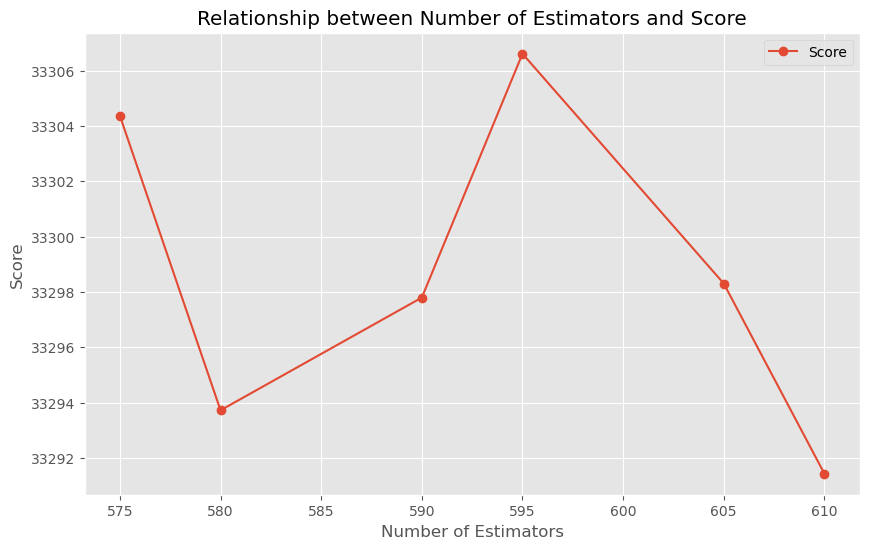

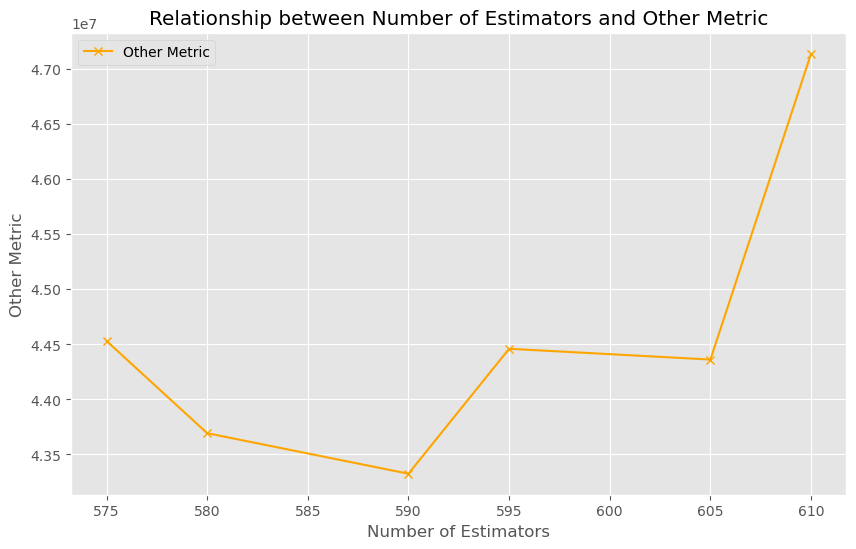

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Creating a DataFrame from the provided data
data = {
    'n_estimators': [575, 590, 610, 580, 595, 605],
    'Score': [33304.366791, 33297.796335, 33291.430575, 33293.723166, 33306.608528, 33298.303194],
    'Other_Metric': [4.453154e+07, 4.332431e+07, 4.714231e+07, 4.369269e+07, 4.446025e+07, 4.436202e+07]
}

df = pd.DataFrame(data)

# Sorting the DataFrame by 'n_estimators'
df_sorted = df.sort_values(by='n_estimators')

# Plotting the relationship for the sorted data
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['n_estimators'], df_sorted['Score'], marker='o', label='Score')
plt.xlabel('Number of Estimators')
plt.ylabel('Score')
plt.title('Relationship between Number of Estimators and Score')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_sorted['n_estimators'], df_sorted['Other_Metric'], marker='x', label='Other Metric', color='orange')
plt.xlabel('Number of Estimators')
plt.ylabel('Other Metric')
plt.title('Relationship between Number of Estimators and Other Metric')
plt.legend()
plt.grid(True)
plt.show()


# ensemble

In [57]:
class AverageWeight(BaseEstimator, RegressorMixin):
    def __init__(self,mod,weight):
        self.mod = mod
        self.weight = weight
        
    def fit(self,X,y):
        self.models_ = [clone(x) for x in self.mod]
        for model in self.models_:
            model.fit(X,y)
        return self
    
    def predict(self,X):
        w = list()
        pred = np.array([model.predict(X) for model in self.models_])
        # for every data point, single model prediction times weight, then add them together
        for data in range(pred.shape[1]):
            single = [pred[model,data]*weight for model,weight in zip(range(pred.shape[0]),self.weight)]
            w.append(np.sum(single))
        return w

In [58]:
xgb=XGBRegressor()
rf=RandomForestRegressor(600,n_jobs=-1)
extra=ExtraTreesRegressor(n_jobs=-1)

In [59]:
# assign weights based on their gridsearch score
w1 = 0.4
w2 = 0.3
w3 = 0.3



In [60]:
weight_avg = AverageWeight(mod = [rf,xgb,extra],weight=[w1,w2,w3])

In [62]:
score =rmse_cv(weight_avg,full_transformed,train['單價元平方公尺']),  rmse_cv(weight_avg,full_transformed,train['單價元平方公尺']).mean()

In [63]:
score


(array([32999.62780488, 31009.51650425, 31757.48203478, 31938.72835322,
        33098.38619552]),
 32205.570542543817)

In [64]:
weight_avg.fit(full_transformed,train['單價元平方公尺'])


AverageWeight(mod=[RandomForestRegressor(n_estimators=600, n_jobs=-1),
                   XGBRegressor(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=None, device=None,
                                early_stopping_rounds=None,
                                enable_categorical=False, eval_metric=None,
                                feature_types=None, gamma=None,
                                grow_policy=None, importance_type=None,
                                interact...raints=None,
                                learning_rate=None, max_bin=None,
                                max_cat_threshold=None, max_cat_to_onehot=None,
                                max_delta_step=None, max_depth=None,
                                max_leaves=None, min_child_weight=None,
                                missing=nan, monotone_constraints=None,
                                multi_strategy=None, n_estimators=None,
                                n_jobs=None, num_parallel_tree=None,
                                random_state=None, ...),
                   ExtraTreesRegressor(n_jobs=-1)],
              weight=[0.4, 0.3, 0.3])

In [65]:
# Apply the pipeline to your data
test = train.copy()
test_transformed = pipeline.fit_transform(test)
 
print(test_transformed)

      鄉鎮市區  交易標的   路名  土地移轉總面積平方公尺  都市土地使用分區  土地數  建物數  車位數  移轉層次  移轉層次項目  \
0        9     1  472        27.75         0  1.0  1.0  1.0     1       6   
1        1     0  546         9.57        19  1.0  1.0  0.0     5       6   
2        9     0  426         9.51         0  1.0  1.0  0.0     1       6   
3        3     1  181        23.67        19  1.0  1.0  1.0    10       6   
4        4     0   77        22.50        19  1.0  1.0  0.0     2       6   
...    ...   ...  ...          ...       ...  ...  ...  ...   ...     ...   
9455    10     0   70        29.01        12  1.0  1.0  0.0     3       6   
9456     9     0  442        20.48         0  2.0  1.0  0.0     2       6   
9457     0     1  120       136.19         0  1.0  1.0  3.0     3       6   
9458     5     1  463        39.45         0  1.0  1.0  1.0    11       6   
9459     4     1  410        30.98        19  1.0  1.0  2.0     2       6   

      總樓層數  建物型態  主要用途  主要建材  建物移轉總面積平方公尺  建物現況格局-房  建物現況格局-廳  建物現況格局-衛  \


In [66]:
res=weight_avg.predict(test_transformed)

In [ ]:
res